In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(0)

X = np.linspace(0, 1, 100)

m_true = 2.5
b_true = -0.5

noise = np.random.uniform(-0.5, 0.5, len(X))
Y = m_true * X + b_true + noise

In [3]:
A = np.vstack([X, np.ones(len(X))]).T
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]

Y_linear = m*X + c

In [4]:
coeffs = np.polyfit(X, Y, 3)
poly = np.poly1d(coeffs)

Y_poly = poly(X)

In [5]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res/ss_tot

In [6]:
mse_linear = mse(Y, Y_linear)
r2_linear = r2(Y, Y_linear)

mse_poly = mse(Y, Y_poly)
r2_poly = r2(Y, Y_poly)

print("Linear Least Squares")
print("MSE:", mse_linear)
print("R²:", r2_linear)

print("\nPolynomial Fit (degree 3)")
print("MSE:", mse_poly)
print("R²:", r2_poly)

Linear Least Squares
MSE: 0.07779921690701527
R²: 0.8468976064277469

Polynomial Fit (degree 3)
MSE: 0.07724582750776272
R²: 0.8479866307774951


In [7]:
if mse_linear < mse_poly:
    print("Linear Least Squares is the better fit.")
else:
    print("Polynomial fit is the better fit.")

Polynomial fit is the better fit.


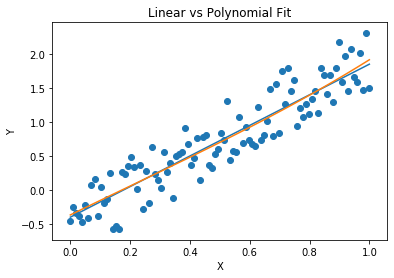

In [8]:
plt.scatter(X, Y)
plt.plot(X, Y_linear)
plt.plot(X, Y_poly)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear vs Polynomial Fit")
plt.show()

In [9]:
degrees = range(1, 11)

for d in degrees:
    coeffs = np.polyfit(X, Y, d)
    poly = np.poly1d(coeffs)

    Y_pred = poly(X)

    print("Degree:", d)
    print("MSE:", mse(Y, Y_pred))
    print("R²:", r2(Y, Y_pred))
    print()

Degree: 1
MSE: 0.07779921690701527
R²: 0.8468976064277469

Degree: 2
MSE: 0.07728793171250467
R²: 0.8479037732015229

Degree: 3
MSE: 0.07724582750776272
R²: 0.8479866307774951

Degree: 4
MSE: 0.0766807536636646
R²: 0.849098649143694

Degree: 5
MSE: 0.07641850254271337
R²: 0.8496147375560316

Degree: 6
MSE: 0.07641850199708272
R²: 0.8496147386297873

Degree: 7
MSE: 0.07640754478876703
R²: 0.8496363015051824

Degree: 8
MSE: 0.07552348629626113
R²: 0.8513760551510616

Degree: 9
MSE: 0.07521795921847349
R²: 0.8519773070501178

Degree: 10
MSE: 0.07510938307443486
R²: 0.8521909758786489



In [10]:
degree = 3

V = np.vander(X, degree+1, increasing=True)

VT_V = np.dot(V.T, V)
VT_y = np.dot(V.T, Y)

coefficients = np.linalg.solve(VT_V, VT_y)

poly = np.poly1d(coefficients[::-1])

Y_vander = poly(X)

print("Vandermonde MSE:", mse(Y, Y_vander))
print("Vandermonde R²:", r2(Y, Y_vander))

Vandermonde MSE: 0.07724582750776272
Vandermonde R²: 0.8479866307774951


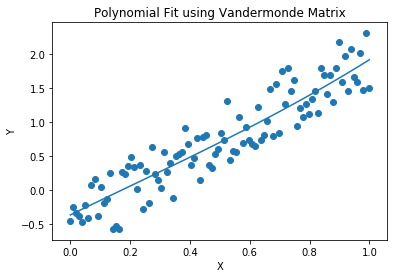

In [11]:
plt.scatter(X, Y)
plt.plot(X, Y_vander)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial Fit using Vandermonde Matrix")
plt.show()